# Crypto perpetuals: features that are themselves model output

Everything this case study has built so far is arithmetic on past bars. A trailing
z-score of the funding rate, a premium percentile, a realized volatility - each is a
formula you could evaluate by hand on a column of numbers. This notebook builds a
different kind of feature. It **fits a statistical model** to the history inside each
cross-validation fold, and then emits what that fitted model says about later bars.

Two models, chosen because they answer questions the arithmetic cannot:

- A **GJR-GARCH(1,1)** volatility model, per perpetual. It estimates how a return
  shock feeds into tomorrow's variance, and separately how much *extra* a downward
  shock feeds in - the asymmetry that a rolling standard deviation averages away.
  Its output is a one-step-ahead conditional volatility for every bar.
- A **two-state Gaussian hidden Markov model**, fitted market-wide on the
  cross-section of realized funding settlements. It estimates two funding regimes and
  the chance of switching between them, and its output is the probability that the
  market is in the stressed one at each settlement.

**Funding**, since the notebook turns on it: a perpetual future never expires, so the
exchange keeps it near the spot price by making one side pay the other a small rate
every eight hours. That rate is the funding settlement, and its cross-section is what
the regime model reads.

**Reads**: `features/financial.parquet`, the feature matrix from
[`03_financial_features`](03_financial_features.ipynb), whose funding-rate column the
regime model is fitted on; `labels/fwd_ret_8h.parquet` from
[`02_labels`](02_labels.ipynb), used only by the evaluation at the end; and the raw
8-hour perpetual bars.

**Writes**: `features/model_based.parquet`, one row per symbol, settlement and fold,
with a digest sidecar beside it. Its reader is `utils.modeling.load_modeling_dataset`,
which every model-fitting notebook from [`06_linear`](06_linear.ipynb) onward calls to
assemble its training frame. The fold column in the artifact is what lets that loader
hand each fold the parameters that were estimated for that fold, rather than one set
for the whole sample.

**What you will be able to do after reading it**

1. Say why a feature built from estimated parameters can look ahead when a feature
   built from past prices cannot, and where the estimation window enters the answer.
2. Fit a volatility model and a regime model separately inside each walk-forward
   fold, on training bars only, and run each one forward over later bars with its
   parameters held fixed.
3. Read a regime probability off a forward pass that has seen only the past, and say
   how it differs from the value the same model reports once it has seen the whole
   series.
4. Check that the fitted parameters actually change as the training window rolls, and
   decide from that whether refitting each fold was worth doing.
5. Measure whether these features rank the cross-section any better than the price and
   funding features already do, correcting the significance test for the number of
   features screened rather than reading each one as if it were the only test run.

**Book reference**: Chapter 9, sections 9.3 (volatility models) and 9.5 (regime
models).

**Prerequisites**: [`02_labels`](02_labels.ipynb) writes the forward-return files;
[`03_financial_features`](03_financial_features.ipynb) writes the feature matrix. The
walk-forward design itself is read from `config/setup.yaml`.

In [1]:
"""Crypto perps funding: model-based features from a GJR-GARCH fit and a funding-regime HMM."""

import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from arch import arch_model
from hmmlearn.hmm import GaussianHMM
from IPython.display import display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series
from threadpoolctl import threadpool_limits

from case_studies.research.holdout import build_holdout_cv
from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.temporal import filtered_state_probs, sort_states_by_variance
from data import load_crypto_perps
from utils.artifact_specs import (
    load_setup_config,
    resolve_label_buffer,
    resolve_label_horizon,
)
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.modeling import load_modeling_dataset, temporal_fold_index
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "crypto_perps_funding"
SEED = 42
MAX_SYMBOLS = 0  # 0 keeps the whole configured universe
_SETUP = load_setup_config(CASE_STUDY_ID)
PRIMARY_LABEL = _SETUP["labels"]["primary"]
MIN_TRAIN_BARS = _SETUP["model_based"]["min_train_bars"]
HMM_N_RESTARTS = _SETUP["model_based"]["hmm"]["n_restarts"]

## Configuration

Everything the two fits decide is declared in `config/setup.yaml` and bound here, so a
number never appears twice. The cell below prints each one as a statement about what
it controls, because a bound value on its own tells a reader nothing about why it
holds that value.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"
FEATURES_DIR = CASE_DIR / "features"

BAR_HOURS = _SETUP["features"]["bar_hours"]
_MODEL_BASED = _SETUP["model_based"]
VOL_ZSCORE_WINDOW = _MODEL_BASED["garch"]["vol_zscore_window"]
VOL_ZSCORE_CLIP = _MODEL_BASED["garch"]["zscore_clip"]
HMM_N_STATES = _MODEL_BASED["hmm"]["n_states"]
MIN_CROSS_SECTION = _MODEL_BASED["incremental_ic"]["min_cross_section"]
MIN_DECISION_TIMES = _MODEL_BASED["incremental_ic"]["min_decision_times"]

LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, _SETUP)
LABEL_HORIZON = resolve_label_horizon(CASE_STUDY_ID, PRIMARY_LABEL, _SETUP)
assert LABEL_BUFFER, f"No label buffer configured for {PRIMARY_LABEL}"
# The Newey-West lag below is counted in decision timestamps, not in hours, so the
# configured horizon is converted into settlement bars once, here.
LABEL_HORIZON_BARS = round(pd.Timedelta(LABEL_BUFFER) / pd.Timedelta(hours=BAR_HOURS))

set_global_seeds(SEED)

In [4]:
_days = VOL_ZSCORE_WINDOW * BAR_HOURS / 24
print(f"Perpetual funding settles every {BAR_HOURS} hours, so a bar is one settlement.")
print(
    f"A symbol is fitted only where its fold training window holds {MIN_TRAIN_BARS:,} "
    f"settlements ({MIN_TRAIN_BARS * BAR_HOURS / 24:.0f} days); a newer listing is left "
    "out of that fold rather than fitted on too short a sample."
)
print(
    f"The regime model has {HMM_N_STATES} states and is refitted from "
    f"{HMM_N_RESTARTS} starting points per fold, keeping the highest training "
    "likelihood, because the fitting algorithm only finds a local optimum."
)
print(
    f"The volatility z-score compares a forecast against its own trailing "
    f"{VOL_ZSCORE_WINDOW} settlements ({_days:.0f} days) and is bounded at "
    f"+/-{VOL_ZSCORE_CLIP:g} so one liquidation cascade cannot set the scale."
)
print(
    f"The evaluation at the end reads a settlement only where at least "
    f"{MIN_CROSS_SECTION} symbols quote at it, and reports a feature only where at "
    f"least {MIN_DECISION_TIMES} such settlements remain."
)
print(
    f"The label being predicted is {PRIMARY_LABEL}, which resolves "
    f"{LABEL_HORIZON_BARS} settlement(s) after the decision (buffer {LABEL_BUFFER})."
)

Perpetual funding settles every 8 hours, so a bar is one settlement.
A symbol is fitted only where its fold training window holds 500 settlements (167 days); a newer listing is left out of that fold rather than fitted on too short a sample.
The regime model has 2 states and is refitted from 10 starting points per fold, keeping the highest training likelihood, because the fitting algorithm only finds a local optimum.
The volatility z-score compares a forecast against its own trailing 90 settlements (30 days) and is bounded at +/-10 so one liquidation cascade cannot set the scale.
The evaluation at the end reads a settlement only where at least 10 symbols quote at it, and reports a feature only where at least 20 such settlements remain.
The label being predicted is fwd_ret_8h, which resolves 1 settlement(s) after the decision (buffer 8H).


## A. Why a fitted feature is different

A feature such as `premium_vol_24h` is a function of past bars. Hand it the bars up to
a given settlement and it returns the same number every time, whatever else is in the
file. There is only one way to make it look ahead, and that is to feed it a bar from
after the decision.

A conditional volatility from a GARCH fit is not like that. It is a function of
*parameters*, and those parameters were **estimated from** a stretch of bars. So the
estimation window is part of the feature's information set, and it is invisible in the
output: two files of conditional volatilities can be identical in shape, in column
names and in plausibility, and one of them can carry the whole sample's information
into every row while the other carries only the past. Nothing about the number says
which.

That gives this stage two ways to look ahead where the last one had one.

**The estimation window can reach past the decision.** Fit the volatility model once
on 2020-2023 and use it to produce a feature for a bar in 2021, and that feature knows
what volatility did in 2022. The discipline that removes it is to fit inside each
fold, on that fold's training bars only, and then hold the parameters fixed while
running the model forward. Nothing is re-estimated once the validation window opens.

**The inference itself can reach past the decision, even from an honest fit.** This
one is specific to state-space models and it is easy to miss. A hidden Markov model
can report the probability of being in a state at time $t$ in two ways. The *filtered*
probability $P(z_t \mid x_{1:t})$ conditions on observations up to and including $t$.
The *smoothed* probability $P(z_t \mid x_{1:T})$ conditions on the whole series,
including everything after $t$; it is what a library returns by default, because for
describing history it is the better estimate. As a feature it is unusable: the value
at a past settlement keeps changing as later settlements arrive, so no live system
could ever have computed it. This notebook emits the filtered probability, and section
C.2 says how.

Both hazards are silent. A notebook with either one runs clean, produces sensible
figures, and reports a plausible information coefficient - a slightly better one, in
fact, which is exactly the problem. So the checks in this notebook are executed
assertions on the fitted windows rather than sentences claiming the windows were
right.

## B. The fold contract

Before anything is fitted, the walk-forward design is resolved: which stretch of
history trains a model, which stretch it is then run forward over, and where the
holdout begins. Doing it first is what lets every fit below be asserted against a
boundary instead of checked against one afterwards.

A **walk-forward** design cuts the history into folds that move through time, each
with a training window followed by a later validation window, so a model is always
scored on bars after the ones it learned from. Between the two sits an **embargo**: a
gap wide enough that the last training decision's outcome has already resolved before
the validation window opens. Without it, the label of the final training bar is
realized inside the validation period, and the model has seen part of what it is about
to be scored on. Here the label is an 8-hour forward return, so the embargo has to be
at least one settlement wide.

The boundaries come from `generate_cv_splits`, which is also what
`load_modeling_dataset` calls downstream, and it is passed the same label buffer and
outcome horizon there as here - so producer and consumer agree by construction rather
than by coincidence. Each fold is then asserted rather than described: the embargo
covers the label buffer, and the last outcome a validation decision resolves into
lands before the holdout opens.

In [5]:
labels = pl.read_parquet(LABELS_DIR / f"{PRIMARY_LABEL}.parquet")
label_col = PRIMARY_LABEL

active_folds = [
    {
        "fold": split["fold"],
        "train_start": split["train_start"],
        "train_end": split["train_end"],
        "test_start": split["val_start"],
        "test_end": split["val_end"],
    }
    for split in generate_cv_splits(
        labels,
        case_study_id=CASE_STUDY_ID,
        label_buffer=LABEL_BUFFER,
        outcome_horizon=LABEL_HORIZON,
        date_col="timestamp",
    )
]
VALIDATION_FOLDS = list(active_folds)
VALIDATION_FOLD_IDS = {fold["fold"] for fold in VALIDATION_FOLDS}
_evaluation = load_evaluation_config(CASE_STUDY_ID)
holdout_start = pd.Timestamp(_evaluation["holdout_start"], tz="UTC")
holdout_end = pd.Timestamp(_evaluation["holdout_end"], tz="UTC")

print(f"Walk-forward folds: {len(VALIDATION_FOLDS)}")
for f in VALIDATION_FOLDS:
    embargo = f["test_start"] - f["train_end"]
    label_endpoint = f["test_end"] + pd.Timedelta(LABEL_BUFFER)
    assert embargo >= pd.Timedelta(LABEL_BUFFER)
    assert label_endpoint < holdout_start
    print(
        f"  Fold {f['fold']}: fitted on [{f['train_start']} to {f['train_end']}], "
        f"run forward over [{f['test_start']} to {f['test_end']}], embargo={embargo}, "
        f"last outcome resolves {label_endpoint}"
    )

Walk-forward folds: 2
  Fold 0: fitted on [2021-01-01 00:00:00+00:00 to 2022-12-31 08:00:00+00:00], run forward over [2023-01-01 00:00:00+00:00 to 2023-12-31 08:00:00+00:00], embargo=0 days 16:00:00, last outcome resolves 2023-12-31 16:00:00+00:00
  Fold 1: fitted on [2020-01-02 00:00:00+00:00 to 2021-12-31 08:00:00+00:00], run forward over [2022-01-01 00:00:00+00:00 to 2022-12-31 16:00:00+00:00], embargo=0 days 16:00:00, last outcome resolves 2023-01-01 00:00:00+00:00


### The holdout fold, which is a fold like the others

The validation folds are what `generate_cv_splits` lays out. One more is appended here, and it
is appended rather than inferred downstream because **a holdout fit needs features, and a split
definition is not features**: `utils.modeling.append_holdout_fold_if_needed` adds the geometry
to a modeling dataset and produces no rows, so a stage that called it against an artifact
written without this found nothing in the holdout window at any fold. That is
ml4t/agent-workspace#971, and this is crypto's half of it.

Its boundaries are not re-derived here. `build_holdout_cv` is what reconstructs a holdout fit
downstream, so it is asked for them: a second construction is a second thing to keep in step,
and this seal has already been built more than once.

The boundary that matters is `train_end`, and it is not the date the holdout opens. It is one
label buffer earlier, counted in settlements along this panel's own grid, so the last training
label's outcome window resolves before the holdout rather than inside it. The buffer is the
case study's **widest** declared one - `fwd_ret_24h` at 24H, three settlements - because one
fold serves every label and the widest is the only choice that leaks for none of them.

Nothing else about the notebook changes. Both models are unsupervised, they read prices and
funding and never the label, and neither input series is cut at the boundary here - the fold
list was the only thing keeping rows out of the holdout window.

In [6]:
_derived_holdout_cv = build_holdout_cv(
    {
        "label": PRIMARY_LABEL,
        "computation": {
            "cv": {
                "folds": [
                    {
                        "fold": f["fold"],
                        "train_start": str(f["train_start"]),
                        "train_end": str(f["train_end"]),
                        "val_start": str(f["test_start"]),
                        "val_end": str(f["test_end"]),
                    }
                    for f in VALIDATION_FOLDS
                ]
            }
        },
    },
    case_study=CASE_STUDY_ID,
    timeline=labels["timestamp"].unique().sort().to_list(),
    label=PRIMARY_LABEL,
)
_derived = _derived_holdout_cv["folds"][0]
holdout_fold = {
    "fold": int(_derived["fold"]),
    "train_start": pd.Timestamp(_derived["train_start"], tz="UTC"),
    "train_end": pd.Timestamp(_derived["train_end"]).tz_convert("UTC"),
    "test_start": pd.Timestamp(_derived["val_start"], tz="UTC"),
    "test_end": pd.Timestamp(_derived["val_end"]).tz_convert("UTC"),
}
HOLDOUT_FOLD_ID = holdout_fold["fold"]
assert HOLDOUT_FOLD_ID not in VALIDATION_FOLD_IDS, (
    "the holdout fold takes an id a validation fold already owns, so every consumer joining by "
    "fold id would read holdout-dated rows as validation data"
)
assert holdout_fold["train_end"] < holdout_start, (
    "the holdout fold trains through the boundary, so the last training label resolves inside "
    "the window it is meant to be judged against"
)
assert (holdout_fold["test_start"], holdout_fold["test_end"].date()) == (
    holdout_start,
    holdout_end.date(),
), "the derived holdout interval is not the one setup.yaml declares"
print(
    f"Holdout fold {HOLDOUT_FOLD_ID}: fitted on [{holdout_fold['train_start']} to "
    f"{holdout_fold['train_end']}], run forward over [{holdout_fold['test_start']} to "
    f"{holdout_fold['test_end']}]; the gap is "
    f"{_derived_holdout_cv['request']['label_buffer_steps']} settlements, which is "
    f"{_derived_holdout_cv['request']['label_buffer']} on this grid and the widest buffer "
    f"{_derived_holdout_cv['request']['label_buffer_label']} declares"
)
active_folds = [*VALIDATION_FOLDS, holdout_fold]
FOLDS_BY_DATE = sorted(active_folds, key=lambda item: item["test_start"])

Holdout fold 2: fitted on [2020-01-02 00:00:00+00:00 to 2023-12-30 16:00:00+00:00], run forward over [2024-01-01 00:00:00+00:00 to 2025-12-31 08:00:00+00:00]; the gap is 3 settlements, which is 24H on this grid and the widest buffer fwd_ret_24h declares


The holdout is fitted on nothing and run forward over everything, which is the same
discipline the validation folds get and not a weaker one. Both models here are
unsupervised - they read prices and funding, never the label - so a fit whose estimation
window ends before the holdout can be run forward across it without seeing anything it
should not, and the holdout fold's estimation window ends three settlements before the
holdout opens.

This notebook used to stop at the development folds and say so. What that cost is now
visible: the artifact carried no model-based feature for any holdout date, so a holdout
retrain joined fold 0's features - fitted on a window ending years earlier - or found
nothing at all, and neither failure raised.

The figure is what the assertions above look like drawn. Each fold contributes one
bar for the window every parameter is estimated from and one for the window the frozen
model is run forward over, with the holdout hatched on the right. The fold ids run
backwards in time, because `generate_cv_splits` numbers outward from the most recent
development data, so fold 1's validation year precedes fold 0's.

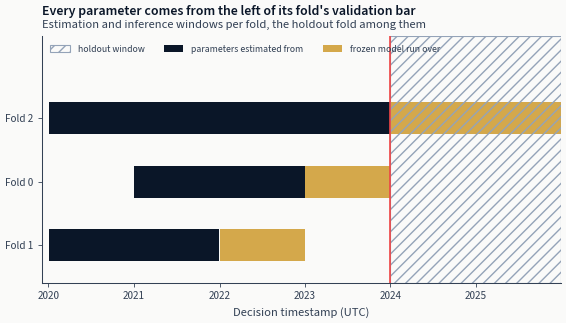

In [7]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for row, fold in enumerate(FOLDS_BY_DATE):
    for start, end, color, name in (
        (fold["train_start"], fold["train_end"], COLORS["blue"], "parameters estimated from"),
        (fold["test_start"], fold["test_end"], COLORS["amber"], "frozen model run over"),
    ):
        ax.barh(
            row, end - start, left=start, height=0.5, color=color, label=name if not row else ""
        )
ax.axvspan(
    holdout_start,
    holdout_end,
    facecolor="none",
    edgecolor=COLORS["recede"],
    hatch="///",
    linewidth=0.8,
    label="holdout window",
)
ax.axvline(holdout_start, color=COLORS["negative"], linewidth=1.2)
ax.set_xlim(min(f["train_start"] for f in active_folds) - pd.Timedelta(days=30), holdout_end)
ax.set_yticks(range(len(active_folds)), [f"Fold {f['fold']}" for f in FOLDS_BY_DATE])
ax.set_ylim(-0.6, len(active_folds) + 0.3)
ax.set(xlabel="Decision timestamp (UTC)")
ax.legend(frameon=False, fontsize=7, loc="upper left", ncols=3)
add_message_title(
    ax,
    "Every parameter comes from the left of its fold's validation bar",
    subtitle="Estimation and inference windows per fold, the holdout fold among them",
)
fig.tight_layout()
show_with_alt(
    fig,
    "Horizontal bars for each fold: a dark estimation window followed by an amber inference "
    "window. Every validation fold's pair ends before a hatched holdout region that begins at "
    "the configured holdout start date; the holdout fold's estimation bar stops just short of "
    "that boundary and its inference bar is the hatched region itself.",
)

### The panel the models are fitted on

The universe is the perpetuals `config/setup.yaml` declares, and the panel is
**unbalanced**: a contract enters it on the day the exchange listed it, and there is
no backfill before that. That matters more here than it did in the last notebook, because a rolling
window can start returning values a few bars after a listing while a fitted model
cannot: it needs enough history for the parameters to be identified at all.

The frame the models read is the financial feature matrix joined to the label, which
is also the frame the evaluation at the end scores against. The raw 8-hour bars are
loaded separately for the volatility model, timestamped at the close of each bar
rather than its open, so a feature at a settlement uses only bars that had finished by
then.

One detail of the plumbing is worth fixing here rather than discovering later. Both
models run through pandas and hand their rows back stamped to the microsecond, while
every frame read off disk is stamped to the millisecond, and the two are joined on the
timestamp. So the panel's own resolution is read once, below, and each model's output
is cast to it as that output is built - rather than at whichever join first refuses.

In [8]:
financial = pl.read_parquet(FEATURES_DIR / "financial.parquet")
financial_feature_cols = [c for c in financial.columns if c not in ("timestamp", "symbol")]
# Hashed as read, before any filtering below, so the artifact this notebook writes
# records what it was actually built from.
FINANCIAL_DIGEST = value_digest(financial)

training_frame = financial.join(labels, on=["timestamp", "symbol"], how="inner").select(
    ["timestamp", "symbol", *financial_feature_cols, label_col]
)
if MAX_SYMBOLS > 0:
    # Most rows first, with the symbol name as an explicit tie-break: row counts tie
    # readily on this panel, and a tie broken by frame order is not stable across runs.
    keep = (
        training_frame.group_by("symbol")
        .len()
        .sort(["len", "symbol"], descending=[True, False])
        .head(MAX_SYMBOLS)["symbol"]
        .to_list()
    )
    training_frame = training_frame.filter(pl.col("symbol").is_in(keep))
symbols = sorted(training_frame["symbol"].unique().to_list())
financial = financial.filter(pl.col("symbol").is_in(symbols))
training_frame = training_frame.sort(["timestamp", "symbol"])

prices = (
    load_crypto_perps(frequency=f"{BAR_HOURS}h")
    .filter(pl.col("symbol").is_in(symbols))
    .with_columns((pl.col("timestamp") + pl.duration(hours=BAR_HOURS)).alias("timestamp"))
    .sort(["symbol", "timestamp"])
)
n_symbols = len(symbols)
_missing = {"timestamp", "symbol", "close"} - set(prices.columns)
assert not _missing, f"the perpetual loader no longer returns {_missing}"
TIMESTAMP_DTYPE = financial.schema["timestamp"]

print(f"Feature matrix: {len(financial):,} rows x {len(financial_feature_cols)} features")
print(f"Joined to {PRIMARY_LABEL}: {len(training_frame):,} rows, {n_symbols} symbols")
print(f"Perpetual bars available: {prices['timestamp'].min()} to {prices['timestamp'].max()}")

Feature matrix: 99,877 rows x 39 features
Joined to fwd_ret_8h: 99,851 rows, 19 symbols
Perpetual bars available: 2020-01-01 08:00:00+00:00 to 2026-01-01 00:00:00+00:00


The chart puts each symbol's available history against the two training windows. Read
it for where a bar starts: a perpetual whose listing falls inside or after a training
window has no history to fit in that fold, and the volatility model simply produces
nothing for it there. Those gaps are why the emitted artifact covers fewer symbols
than the universe configures, and the count is printed with each fold below rather
than left to be discovered downstream.

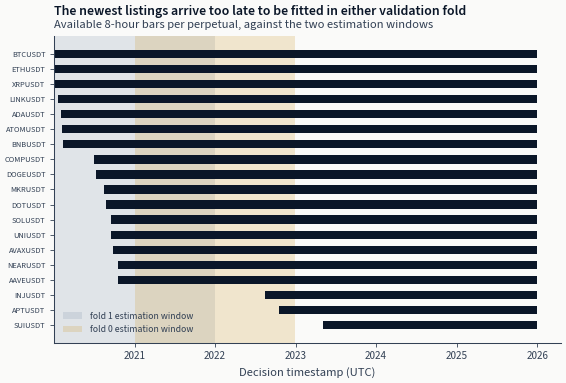

In [9]:
coverage = (
    prices.group_by("symbol")
    .agg(pl.col("timestamp").min().alias("first"), pl.col("timestamp").max().alias("last"))
    .sort("first", descending=True)
)
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
_VALIDATION_BY_DATE = [f for f in FOLDS_BY_DATE if f["fold"] in VALIDATION_FOLD_IDS]
for fold, color in zip(_VALIDATION_BY_DATE, (COLORS["recede"], COLORS["amber"]), strict=False):
    ax.axvspan(
        fold["train_start"],
        fold["train_end"],
        color=color,
        alpha=0.25,
        linewidth=0,
        label=f"fold {fold['fold']} estimation window",
    )
ax.barh(
    coverage["symbol"].to_list(),
    (coverage["last"] - coverage["first"]).to_list(),
    left=coverage["first"].to_list(),
    height=0.55,
    color=COLORS["blue"],
)
ax.set(xlabel="Decision timestamp (UTC)")
ax.tick_params(axis="y", labelsize=6)
ax.legend(frameon=False, fontsize=7, loc="lower left")
add_message_title(
    ax,
    "The newest listings arrive too late to be fitted in either validation fold",
    subtitle="Available 8-hour bars per perpetual, against the two estimation windows",
)
fig.tight_layout()
show_with_alt(
    fig,
    "Horizontal bars showing each perpetual's span of available 8-hour bars, sorted by "
    "listing date, with the two shaded fold estimation windows behind them; the three "
    "most recent listings begin inside or after the later window.",
)

## C. The two fitted models

Each of the two gets the same treatment, and the shape is worth naming once because it
is the whole discipline of this stage: fit on the fold's training bars, freeze the
parameters, run the model forward over training and validation bars alike, and then
assert - in code that fails the notebook - that the bars the fit consumed all lie
inside the training window.

### C.1 Conditional volatility, per perpetual

**GARCH** models let today's variance depend on yesterday's variance and yesterday's
squared return, which is why a quiet week tends to be followed by a quiet day and a
violent one by another violent one. **GJR-GARCH** adds one term: a squared return
counts for more when the return was negative. That asymmetry is the reason to fit a
model here rather than take a rolling standard deviation, which weights a fall and an
equally large rise identically. In crypto perpetuals the difference is large, because
a fall liquidates leveraged longs and the forced selling moves price again.

Written out, the variance recursion is

$$h_t = \omega + \alpha \varepsilon_{t-1}^2 + \gamma \varepsilon_{t-1}^2
  \mathbb{1}[\varepsilon_{t-1} < 0] + \beta h_{t-1}$$

where $\varepsilon_t$ is the return, $\alpha$ is how much an ordinary shock feeds
through, $\gamma$ the extra a downward shock feeds through, and $\beta$ how much of
yesterday's variance carries into today. Innovations are drawn from a Student-t
distribution rather than a normal one, because 8-hour crypto returns have far more
extreme observations than a normal distribution admits, and a normal fit compensates
by inflating $\omega$ for every bar.

In [10]:
def between(data, start: pd.Timestamp, end: pd.Timestamp):
    """The part of a time-indexed series or frame inside a closed interval."""
    return data.loc[(data.index >= start) & (data.index <= end)]


def fit_gjr_garch(returns: pd.Series) -> dict | None:
    """Fit GJR-GARCH(1,1) with Student-t innovations on one symbol's training returns."""
    if len(returns) < 100 or returns.std() < 1e-10:
        return None
    try:
        model = arch_model(returns * 100, mean="Zero", vol="GARCH", p=1, o=1, q=1, dist="StudentsT")
        result = model.fit(disp="off", show_warning=False)
    except Exception:
        return None
    return {
        "params": result.params,
        "gamma": result.params.get("gamma[1]", 0),
        "coefficients": {
            name: float(result.params.get(f"{name}[1]", float("nan")))
            for name in ("alpha", "gamma", "beta")
        },
    }

Fitting and filtering are two calls, and the split is the point. `fit` searches for
the parameters that best explain the training returns; `fix` takes parameters it is
given and only runs the variance recursion with them. Handing `fix` the training and
validation returns together produces a conditional variance for every bar in the fold,
and the parameters in that recursion still came from the training window alone.

One step of arithmetic is added on top of what the library returns, and it is worth
following because the same off-by-one sits in any volatility feature built this way.
A library's conditional variance at bar $t$ is the variance **of** that bar: it is
built from the shock at $t-1$, so it is what a forecaster standing at $t-1$ would have
said about the bar now ending. A decision taken at $t$ has already seen the return
that just landed, so emitting that number at $t$ throws away the most recent
observation - the one a volatility model weights most heavily. Advancing the recursion
by one step, $h_{t+1} = \omega + (\alpha + \gamma \mathbb{1}[\varepsilon_t < 0])
\varepsilon_t^2 + \beta h_t$, gives the variance of the bar the decision at $t$ is
actually exposed to, and every term on the right is known at $t$.

In [11]:
def frozen_garch_path(close: pd.Series, fold: dict, params: pd.Series) -> pd.Series | None:
    """One-step-ahead conditional volatility at each bar, with the parameters held fixed."""
    path_returns = between(close, fold["train_start"], fold["test_end"]).pct_change().dropna()
    try:
        fixed = arch_model(
            path_returns * 100, mean="Zero", vol="GARCH", p=1, o=1, q=1, dist="StudentsT"
        ).fix(params)
    except Exception:
        return None
    omega, alpha, gamma, beta = (
        float(params[name]) for name in ("omega", "alpha[1]", "gamma[1]", "beta[1]")
    )
    shock = (path_returns * 100).to_numpy()
    variance = fixed.conditional_volatility.to_numpy() ** 2
    forecast = omega + (alpha + gamma * (shock < 0)) * shock**2 + beta * variance
    return pd.Series(np.sqrt(forecast) / 100, index=path_returns.index)

One symbol at a time, the extraction below slices the training returns, fits, runs the
frozen recursion, and returns both the feature rows and the interval the fit actually
consumed. That interval is what the assertion after the loop reads. Prose saying a fit
stayed inside its training window is worth nothing on its own; the check has to
recompute the window from the fit that ran.

In [12]:
def extract_symbol_garch(
    close: pd.Series, symbol: str, fold: dict
) -> tuple[list[dict], dict | None]:
    """Return one symbol's fold-specific volatility rows and what its fit consumed."""
    train_returns = between(close, fold["train_start"], fold["train_end"]).pct_change().dropna()
    test_close = between(close, fold["test_start"], fold["test_end"])
    if len(train_returns) < MIN_TRAIN_BARS or test_close.empty:
        return [], None
    fitted = fit_gjr_garch(train_returns)
    if fitted is None:
        return [], None
    conditional_vol = frozen_garch_path(close, fold, fitted["params"])
    if conditional_vol is None:
        return [], None
    rows = [
        {
            "timestamp": pd.Timestamp(ts, tz="UTC") if ts.tzinfo is None else ts,
            "symbol": symbol,
            "garch_cond_vol": float(vol),
            "garch_asymmetry": float(fitted["gamma"]),
            "fold": fold["fold"],
        }
        for ts, vol in conditional_vol.items()
    ]
    provenance = {
        "fold": fold["fold"],
        "symbol": symbol,
        "fit_start": train_returns.index.min(),
        "fit_end": train_returns.index.max(),
        "n_fit": len(train_returns),
        **fitted["coefficients"],
    }
    return rows, provenance

The loop is orchestration only. Each `(fold, symbol)` pair is independent, and the
success count printed per fold is the number of perpetuals whose training window held
enough history to fit.

In [13]:
close_by_symbol = {
    symbol: prices.filter(pl.col("symbol") == symbol)
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")["close"]
    for symbol in symbols
}

garch_results = []
garch_provenance = []
for fold in active_folds:
    fold_rows = []
    for symbol in symbols:
        rows, provenance = extract_symbol_garch(close_by_symbol[symbol], symbol, fold)
        fold_rows.extend(rows)
        if provenance is not None:
            garch_provenance.append(provenance)
    garch_results.extend(fold_rows)
    fitted_symbols = len({row["symbol"] for row in fold_rows})
    print(f"Fold {fold['fold']}: volatility model fitted for {fitted_symbols}/{n_symbols} symbols")

Fold 0: volatility model fitted for 16/19 symbols


Fold 1: volatility model fitted for 16/19 symbols


Fold 2: volatility model fitted for 19/19 symbols


The seal, recomputed from what each fit consumed rather than asserted in prose. Every
fit interval has to sit inside its own fold's training window, which also means none
of them reaches the embargo, the validation window, or the holdout.

In [14]:
garch_windows = pl.DataFrame(garch_provenance)
fold_bounds = pl.DataFrame(
    {
        "fold": [f["fold"] for f in active_folds],
        "train_start": [f["train_start"] for f in active_folds],
        "train_end": [f["train_end"] for f in active_folds],
        "test_start": [f["test_start"] for f in active_folds],
    }
)
_sealed = garch_windows.join(fold_bounds, on="fold", how="inner")
assert len(_sealed) == len(garch_windows), "a fit was recorded against an unknown fold"
assert (_sealed["fit_start"] >= _sealed["train_start"]).all(), "a fit began before its fold"
assert (_sealed["fit_end"] <= _sealed["train_end"]).all(), "a fit read past its training window"
assert (_sealed["fit_end"] < _sealed["test_start"]).all(), "a fit reached the validation window"
print(
    f"{len(_sealed)} volatility fits, every one inside its fold's training window; "
    f"the latest bar any of them read is {_sealed['fit_end'].max()}, and the earliest "
    f"validation window opens {_sealed['test_start'].min()}"
)

51 volatility fits, every one inside its fold's training window; the latest bar any of them read is 2023-12-30 16:00:00+00:00, and the earliest validation window opens 2022-01-01 00:00:00+00:00


One derived column follows. The conditional volatility is a level, and a level is hard
to compare across perpetuals whose typical volatility differs by a factor of three, so
a z-score against each symbol's own trailing window says whether *this* symbol is
currently agitated relative to its own recent norm. It is computed within
`(fold, symbol)` so the trailing window never crosses a fold boundary, and its warm-up
stays null rather than being filled: the models downstream impute inside each fold.

In [15]:
garch_df = pl.DataFrame(garch_results)
if garch_df.is_empty():
    raise RuntimeError("No volatility features produced")
garch_df = garch_df.with_columns(pl.col("timestamp").cast(TIMESTAMP_DTYPE))
garch_df = garch_df.sort(["fold", "symbol", "timestamp"]).with_columns(
    (
        (
            pl.col("garch_cond_vol")
            - pl.col("garch_cond_vol")
            .rolling_mean(window_size=VOL_ZSCORE_WINDOW)
            .over(["fold", "symbol"])
        )
        / pl.col("garch_cond_vol")
        .rolling_std(window_size=VOL_ZSCORE_WINDOW)
        .over(["fold", "symbol"])
        .clip(lower_bound=1e-10)
    )
    .clip(-VOL_ZSCORE_CLIP, VOL_ZSCORE_CLIP)
    .alias("garch_vol_zscore")
)
print(f"Volatility features: {len(garch_df):,} rows")

Volatility features: 206,268 rows


### C.2 Funding regimes, market-wide

The second model asks a question about the market rather than about a symbol. Funding
on a perpetual is the periodic payment between long and short holders that keeps the
contract near spot; when the whole universe is paying heavily in one direction, and
disagreeing about how much, the market is in a different state from a quiet week. A
**hidden Markov model** formalizes exactly that: it assumes an unobserved state that
switches between a small number of values, with a probability of switching estimated
from the data, and it assumes what you observe is drawn from a distribution that
depends on which state you are in.

The observation here is two-dimensional per settlement: the cross-sectional mean of
realized funding across the perpetuals quoting at that settlement, and its
cross-sectional standard deviation, both in basis points. Mean gives the direction the
market is paying, dispersion gives how much the contracts disagree. Two states is what
the notebook fits, and the state with the larger fitted dispersion is named the
stressed one - the naming has to be a property of the fit and not an accident of
labelling, because the algorithm returns the states in an arbitrary order and the same
regime can come back as state 0 in one fold and state 1 in the next.

In [16]:
agg_series = (
    financial.select("timestamp", "symbol", "funding_rate")
    .with_columns((pl.col("funding_rate") * 10_000).alias("funding_bps"))
    .group_by("timestamp")
    .agg(
        pl.col("funding_bps").mean().alias("xs_mean_funding_bps"),
        pl.col("funding_bps").std().alias("xs_std_funding_bps"),
        pl.col("funding_bps").count().alias("n_contracts"),
    )
    .filter(pl.col("n_contracts") >= 2)
    .select("timestamp", "xs_mean_funding_bps", "xs_std_funding_bps")
    .sort("timestamp")
    .drop_nulls()
)
print(f"Settlements the regime model reads: {len(agg_series):,}")

Settlements the regime model reads: 6,314


Two shared helpers do the work that must be identical everywhere it is used.
`filtered_state_probs` runs the forward recursion that gives $P(z_t \mid x_{1:t})$
rather than the smoothed posterior a library returns by default, and
`sort_states_by_variance` puts the states in dispersion order so state 0 means the
same thing in every fold. They live in `case_studies/utils/temporal.py` because a
regime feature is only comparable across folds if every notebook orders its states the
same way, and because the forward recursion reaches a private method of the modelling
library that should be named in one place rather than several.

The fit itself is held to a single compute thread. The library initializes through
k-means, whose partial sums are reduced across threads, and floating-point addition is
not associative - so the starting means depend on how the work happened to be split,
expectation-maximization carries that into the transition matrix, so two runs on a
machine that was busier or quieter can emit different probabilities from the same
data. A seed fixes the draw and not the schedule; holding the fit to one thread fixes
both, and here it costs seconds because the observation is two columns wide.

In [17]:
def fit_best_hmm(x_train: np.ndarray) -> tuple[GaussianHMM | None, float]:
    """Return the restart with the highest training likelihood, fitted reproducibly."""
    best_model, best_ll = None, -np.inf
    with threadpool_limits(limits=1):
        for seed in range(HMM_N_RESTARTS):
            try:
                model = GaussianHMM(
                    n_components=HMM_N_STATES,
                    covariance_type="full",
                    n_iter=200,
                    random_state=seed,
                    tol=1e-4,
                )
                model.fit(x_train)
                log_likelihood = model.score(x_train)
                if log_likelihood > best_ll:
                    best_ll, best_model = log_likelihood, model
            except Exception:
                continue
    return best_model, best_ll

The extraction below fits on the fold's training settlements, then runs the forward
recursion over training and validation settlements together. Running it over the
joined stretch is not a shortcut: the filter needs the training observations to arrive
at the state distribution it holds when the validation window opens, and because the
recursion only ever looks backwards, a validation settlement's probability depends on
nothing after it.

In [18]:
def extract_hmm_fold(agg_pd: pd.DataFrame, fold: dict) -> tuple[list[dict], dict] | None:
    """Fit one regime model and return its filtered path plus what the fit consumed."""
    observed = agg_pd[["xs_mean_funding_bps", "xs_std_funding_bps"]].dropna()
    train_data = between(observed, fold["train_start"], fold["train_end"])
    test_data = between(observed, fold["test_start"], fold["test_end"])
    if len(train_data) < MIN_TRAIN_BARS or test_data.empty:
        return None
    model, log_likelihood = fit_best_hmm(train_data.values)
    if model is None:
        return None
    order = sort_states_by_variance(model)
    path_data = between(observed, fold["train_start"], fold["test_end"])
    probabilities = filtered_state_probs(model, path_data.values)[:, order]
    timestamps = path_data.index
    rows = [
        {
            "timestamp": pd.Timestamp(ts, tz="UTC") if ts.tzinfo is None else ts,
            "hmm_regime_prob_calm": float(probabilities[idx, 0]),
            "hmm_regime_prob_stress": float(probabilities[idx, 1]),
            "fold": fold["fold"],
        }
        for idx, ts in enumerate(timestamps)
    ]
    transition = model.transmat_[np.ix_(order, order)]
    # Expected run length of a state whose per-settlement chance of staying is p is
    # 1 / (1 - p) settlements.
    durations = 1.0 / (1.0 - np.diag(transition) + 1e-10)
    diagnostics = {
        "log_likelihood": log_likelihood,
        "fit_start": train_data.index.min(),
        "fit_end": train_data.index.max(),
        "n_fit": len(train_data),
        "calm_duration_bars": float(durations[0]),
        "stress_duration_bars": float(durations[1]),
    }
    return rows, diagnostics

In [19]:
hmm_results = []
hmm_diagnostics = []
agg_pd = agg_series.to_pandas().set_index("timestamp")
for fold in active_folds:
    extracted = extract_hmm_fold(agg_pd, fold)
    if extracted is None:
        raise RuntimeError(f"Fold {fold['fold']}: regime model could not be fitted")
    rows, diagnostics = extracted
    hmm_results.extend(rows)
    hmm_diagnostics.append({"fold": fold["fold"], **diagnostics})
hmm_df = pl.DataFrame(hmm_results).with_columns(pl.col("timestamp").cast(TIMESTAMP_DTYPE))
print(f"Regime probabilities: {len(hmm_df):,} settlements across {len(active_folds)} folds")

Regime probabilities: 12,452 settlements across 3 folds


The same seal as the volatility model, recomputed from the settlements each regime fit
consumed.

In [20]:
_hmm_sealed = pl.DataFrame(hmm_diagnostics).join(fold_bounds, on="fold", how="inner")
assert len(_hmm_sealed) == len(hmm_diagnostics), "a fit was recorded against an unknown fold"
assert (_hmm_sealed["fit_start"] >= _hmm_sealed["train_start"]).all(), "a fit began before its fold"
assert (_hmm_sealed["fit_end"] <= _hmm_sealed["train_end"]).all(), "a fit read past training"
assert (_hmm_sealed["fit_end"] < _hmm_sealed["test_start"]).all(), "a fit reached validation"
display(_hmm_sealed.select("fold", "n_fit", "fit_start", "fit_end", "log_likelihood"))

fold,n_fit,fit_start,fit_end,log_likelihood
i64,i64,"datetime[μs, UTC]","datetime[μs, UTC]",f64
0,2018,2021-01-01 00:00:00 UTC,2022-12-31 08:00:00 UTC,-6320.016241
1,1930,2020-01-31 08:00:00 UTC,2021-12-31 08:00:00 UTC,-8221.420115
2,4118,2020-01-31 08:00:00 UTC,2023-12-30 16:00:00 UTC,-13800.361635


The figure below is what a filtered regime probability looks like, drawn against the
series it was inferred from so the two can be read together. The top panel is the
cross-sectional funding the model observes; the bottom is the probability it assigns
to the stressed state, on validation settlements only, so every value shown comes from
a model fitted on earlier bars. Read the bottom panel for how the probability behaves,
not for where it happens to be high: it moves between its bounds within a day rather
than drifting, which is the signature of a filter that revises hard on each new
observation and is what makes the feature a state indicator rather than a trend.

In [21]:
regime_view = pl.concat(
    [
        hmm_df.filter(
            (pl.col("fold") == fold["fold"])
            & pl.col("timestamp").is_between(fold["test_start"], fold["test_end"], closed="both")
        ).join(agg_series, on="timestamp", how="inner")
        for fold in _VALIDATION_BY_DATE
    ]
).sort("timestamp")

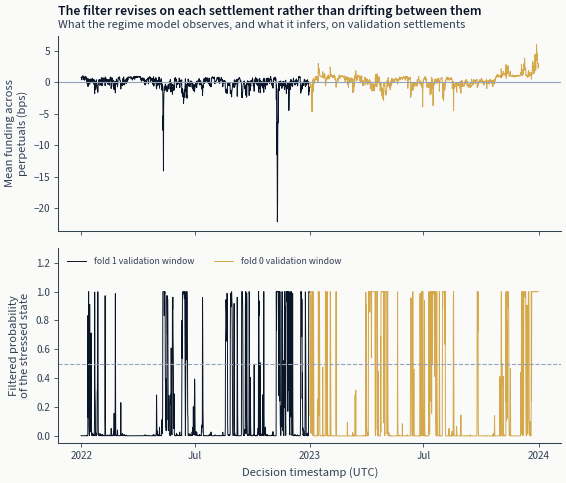

In [22]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], sharex=True)
for color, fold in zip((COLORS["blue"], COLORS["amber"]), _VALIDATION_BY_DATE, strict=False):
    window = regime_view.filter(pl.col("fold") == fold["fold"])
    stamps = window["timestamp"].to_list()
    axes[0].plot(stamps, window["xs_mean_funding_bps"].to_list(), color=color, linewidth=0.7)
    axes[1].plot(
        stamps,
        window["hmm_regime_prob_stress"].to_list(),
        color=color,
        linewidth=0.7,
        label=f"fold {fold['fold']} validation window",
    )
axes[0].axhline(0, color=COLORS["recede"], linewidth=0.8)
axes[0].set_ylabel("Mean funding across\nperpetuals (bps)")
axes[1].axhline(0.5, color=COLORS["recede"], linewidth=0.8, linestyle="--")
axes[1].set_ylim(-0.05, 1.3)
axes[1].set(xlabel="Decision timestamp (UTC)", ylabel="Filtered probability\nof the stressed state")
axes[1].legend(loc="upper left", ncols=2, frameon=False, fontsize=7)
_locator = mdates.AutoDateLocator(maxticks=7)
axes[1].xaxis.set_major_locator(_locator)
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(_locator))
add_message_title(
    axes[0],
    "The filter revises on each settlement rather than drifting between them",
    subtitle="What the regime model observes, and what it infers, on validation settlements",
)
fig.tight_layout()
show_with_alt(
    fig,
    "Two stacked time-series panels over the two validation windows: the upper shows "
    "mean cross-sectional funding in basis points oscillating around zero, the lower "
    "shows the filtered stressed-state probability switching sharply between zero and "
    "one rather than moving smoothly.",
)

## D. Do the fitted parameters move as the window rolls?

Both models are refitted once per fold, and that choice is only worth its cost if the
estimates actually move. A model whose parameters come back identical fold to fold is
telling you the refit bought nothing and a single fit would have done. One whose
parameters swing is telling you something more useful and more uncomfortable: the
feature it produces means a different thing in each fold, which the notebooks that
pool folds downstream need to know.

The two models get a chart each, because their units do not compare: a recursion
coefficient is dimensionless and a regime duration is counted in settlements.

What is plotted for the volatility model is **persistence**, $\alpha + \beta +
\gamma/2$ - the fraction of a variance shock still present one settlement later, with
the asymmetry term at half weight because it is active on the half of settlements that
fall. Persistence is the quantity to read rather than any single coefficient, because
the coefficients trade off against each other: one can rise while another falls and
leave the decay rate unchanged, so a claim of stability read off $\alpha$ alone can be
wrong in either direction. The model is fitted per perpetual, so the median across
symbols is drawn with the interquartile range behind it. For the regime model the
quantity is the expected run length of each state, in settlements.

In [23]:
FOLD_ORDER = [fold["fold"] for fold in sorted(active_folds, key=lambda item: item["test_start"])]
GARCH_COEFFICIENTS = ["alpha", "gamma", "beta"]

coefficient_frame = garch_windows.with_columns(
    (pl.col("alpha") + pl.col("beta") + pl.col("gamma") / 2).alias("persistence")
)
coefficient_stability = (
    coefficient_frame.group_by("fold")
    .agg(
        [
            expression
            for name in [*GARCH_COEFFICIENTS, "persistence"]
            for expression in (
                pl.col(name).median().alias(f"{name}_median"),
                pl.col(name).quantile(0.25).alias(f"{name}_q25"),
                pl.col(name).quantile(0.75).alias(f"{name}_q75"),
            )
        ]
    )
    .sort(pl.col("fold").replace_strict(FOLD_ORDER, range(len(FOLD_ORDER))))
)
duration_stability = pl.DataFrame(hmm_diagnostics).sort(
    pl.col("fold").replace_strict(FOLD_ORDER, range(len(FOLD_ORDER)))
)
display(
    coefficient_stability.select(
        "fold", *[f"{n}_median" for n in [*GARCH_COEFFICIENTS, "persistence"]]
    )
)
display(duration_stability.select("fold", "calm_duration_bars", "stress_duration_bars"))

fold,alpha_median,gamma_median,beta_median,persistence_median
i64,f64,f64,f64,f64
1,0.093202,0.035194,0.861694,0.977668
0,0.075554,0.034296,0.90468,1.0
2,0.087468,0.003885,0.916591,1.0


fold,calm_duration_bars,stress_duration_bars
i64,f64,f64
1,13.064628,10.223241
0,26.711721,14.028788
2,17.386449,10.068293


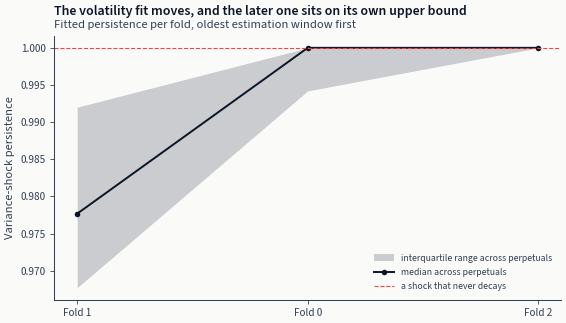

In [24]:
POSITIONS = list(range(len(FOLD_ORDER)))
FOLD_TICKS = [f"Fold {value}" for value in FOLD_ORDER]

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.fill_between(
    POSITIONS,
    coefficient_stability["persistence_q25"].to_list(),
    coefficient_stability["persistence_q75"].to_list(),
    color=COLORS["blue"],
    alpha=0.2,
    linewidth=0,
    label="interquartile range across perpetuals",
)
ax.plot(
    POSITIONS,
    coefficient_stability["persistence_median"].to_list(),
    marker="o",
    color=COLORS["blue"],
    label="median across perpetuals",
)
ax.axhline(1.0, color=COLORS["negative"], lw=0.8, ls="--", label="a shock that never decays")
ax.set_xticks(POSITIONS, FOLD_TICKS)
ax.set_ylabel("Variance-shock persistence")
ax.legend(frameon=False, fontsize=7, loc="lower right")
add_message_title(
    ax,
    "The volatility fit moves, and the later one sits on its own upper bound",
    subtitle="Fitted persistence per fold, oldest estimation window first",
)
fig.tight_layout()
show_with_alt(
    fig,
    "Median variance-shock persistence across perpetuals against fold, with an "
    "interquartile band, rising from below the dashed line marking a shock that never "
    "decays to sitting on it in the later fold.",
)

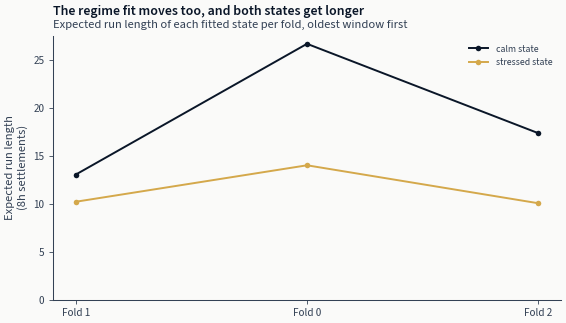

In [25]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for column, name, color in (
    ("calm_duration_bars", "calm state", COLORS["blue"]),
    ("stress_duration_bars", "stressed state", COLORS["amber"]),
):
    ax.plot(POSITIONS, duration_stability[column].to_list(), marker="o", color=color, label=name)
ax.set_xticks(POSITIONS, FOLD_TICKS)
ax.set_ylim(bottom=0)
ax.set_ylabel(f"Expected run length\n({BAR_HOURS}h settlements)")
ax.legend(frameon=False, fontsize=7)
add_message_title(
    ax,
    "The regime fit moves too, and both states get longer",
    subtitle="Expected run length of each fitted state per fold, oldest window first",
)
fig.tight_layout()
show_with_alt(
    fig,
    "Expected run length of the calm and the stressed regime against fold, both rising "
    "from the earlier estimation window to the later one.",
)

**The refit is doing something, in both models.** The medians in the tables above move
across the three fits, and for the volatility model two of the three - fold 0 and the
holdout fold - reach the boundary the fitting library imposes at 1.0, with the upper
half of the interquartile range sitting on it: for at least half the perpetuals, those
fits say a variance shock does not decay inside the window at all. A fit at that
boundary is censored there, so it cannot distinguish "extremely persistent" from
"integrated", and that is the second reason to read persistence rather than a single
coefficient - median $\alpha$ runs 0.093, 0.076, 0.087 across folds 1, 0 and 2 while
$\beta$ runs 0.862, 0.905, 0.917, so either one on its own understates how far the
recursion moved.

The holdout fold is the interesting row, because it is fitted on four years where the
validation folds see two. Its persistence is censored at 1.0 like fold 0's, and its
median $\gamma$ collapses to 0.004 against 0.035 and 0.034 - on the longest window the
asymmetry term all but disappears, which is a statement about how much of it the
two-year windows were fitting to their own sample.

The regime model moves too, and not monotonically: calm run length is 13.1 settlements
in fold 1, 26.7 in fold 0 and 17.4 in the holdout fold, and the stressed state runs
10.2, 14.0 and 10.1. So the state a fit calls calm persists for twice as long in one
window as in another, and the longest window does not simply average them. Neither
`garch_cond_vol` nor
`hmm_regime_prob_stress` is therefore one variable measured three times. A model that
pools folds is pooling quantities calibrated differently, which is what the fold column
in the artifact exists to prevent - and it is why the holdout fold has to be one of the
folds in the file rather than a join against fold 0.

## E. Combine and emit

The two models produce differently shaped output. The volatility model gives one row
per perpetual, settlement and fold; the regime model gives one row per settlement and
fold, because it describes the market rather than any single contract. Combining them
means broadcasting the market-level probabilities across the symbols quoting at each
settlement, which the join below does on all three keys at once so a fold's
probabilities can never attach to another fold's volatility rows.

In [26]:
hmm_broadcast = hmm_df.join(pl.DataFrame({"symbol": symbols}), how="cross").select(
    ["timestamp", "symbol", "fold", "hmm_regime_prob_calm", "hmm_regime_prob_stress"]
)
temporal = (
    garch_df.select(
        ["timestamp", "symbol", "fold", "garch_cond_vol", "garch_vol_zscore", "garch_asymmetry"]
    )
    .join(hmm_broadcast, on=["timestamp", "symbol", "fold"], how="left")
    .sort(["fold", "symbol", "timestamp"])
    .drop_nulls(subset=["garch_cond_vol", "garch_asymmetry"])
)
temporal_feature_cols = [c for c in temporal.columns if c not in ("timestamp", "symbol", "fold")]

Two kinds of missing value survive into the artifact on purpose, and it is worth being
precise about which, because the notebooks downstream impute inside each fold and need
to know what they are imputing. The volatility z-score is null over its trailing
window's warm-up, at the start of each fold. The regime probabilities are null wherever
the perpetual bar grid carries a settlement that the funding panel does not, since the
regime model is fitted on funding and cannot speak about a settlement it never saw. A
probability that was never inferred is left as absent rather than filled with a number
that would read as a confident answer.

In [27]:
display(
    pl.DataFrame(
        {
            "feature": temporal_feature_cols,
            "mean": [temporal[c].mean() for c in temporal_feature_cols],
            "standard_deviation": [temporal[c].std() for c in temporal_feature_cols],
            "null_fraction": [
                temporal[c].null_count() / len(temporal) for c in temporal_feature_cols
            ],
        }
    )
)
print(f"Rows: {len(temporal):,}   symbols: {temporal['symbol'].n_unique()}")
print(f"Period: {temporal['timestamp'].min()} to {temporal['timestamp'].max()}")

feature,mean,standard_deviation,null_fraction
str,f64,f64,f64
"""garch_cond_vol""",0.031859,0.016164,0.0
"""garch_vol_zscore""",-0.029379,1.254279,0.022005
"""garch_asymmetry""",0.017967,0.02997,0.0
"""hmm_regime_prob_calm""",0.728867,0.425345,0.042576
"""hmm_regime_prob_stress""",0.271133,0.425345,0.042576


Rows: 206,268   symbols: 19
Period: 2020-01-02 08:00:00+00:00 to 2025-12-31 08:00:00+00:00


Three guards run before the write, because a feature artifact is read by every model
notebook and a defect in it is cheapest to catch here. The schema is frozen against
the five names this stage contracts to produce, so a renamed or extra column fails
rather than propagating. No `(timestamp, symbol, fold)` key may appear twice, since a
duplicate would silently multiply rows in every join downstream. And nothing may reach
the holdout.

Beside the parquet goes a **digest sidecar**, a small JSON file recording what was
written: a hash taken over the values themselves, the row count, the key columns, and
the same hash taken over each artifact these values were built from. It is computed
over content rather than file bytes, so rewriting the file in a different row order
leaves it alone while changing a single feature value moves it. The input digests are
taken over the frames this notebook read rather than copied from the sidecars beside
them, so what the chain records is what was actually loaded. That is the check the
experiment registry cannot make: the registry records the *name* of a feature set, so
corrected features change every number downstream without changing anything the
registry stores.

In [28]:
EXPECTED_TEMPORAL = {
    "garch_cond_vol",
    "garch_vol_zscore",
    "garch_asymmetry",
    "hmm_regime_prob_calm",
    "hmm_regime_prob_stress",
}
assert set(temporal_feature_cols) == EXPECTED_TEMPORAL, "the emitted schema is not the contract"
assert temporal.select("timestamp", "symbol", "fold").is_duplicated().sum() == 0

# Containment, checked in both directions and per fold class. A one-directional check - "no row
# reaches the holdout" over the whole frame - can only catch an estimate leaking into a period it
# should not describe. It cannot catch the opposite failure, which is a holdout window containing
# nothing at all, and that is the failure this notebook actually had: it passed for months while
# the artifact carried no holdout-dated row of any kind.
_validation_rows = temporal.filter(pl.col("fold").is_in(VALIDATION_FOLD_IDS))
assert _validation_rows["timestamp"].max() < holdout_start, (
    "a validation fold emitted a holdout-dated row"
)
_holdout_rows = temporal.filter(pl.col("fold") == HOLDOUT_FOLD_ID)
assert _holdout_rows["timestamp"].max() <= holdout_fold["test_end"], (
    "the holdout fold emitted a row past the end of the holdout window"
)
_inside = _holdout_rows.filter(pl.col("timestamp") >= holdout_start)
assert _inside.height > 0, (
    "the holdout fold wrote no holdout-dated row, which is the vintage it exists to produce"
)
for column in sorted(EXPECTED_TEMPORAL):
    non_null = _inside.get_column(column).drop_nulls().len()
    assert non_null > 0, (
        f"{column} is null on every holdout-dated row, so the fold is present and the feature "
        "is not - a fit that produced nothing reads exactly like one that was never asked"
    )
print(
    f"Holdout fold {HOLDOUT_FOLD_ID}: {_inside.height:,} rows inside the holdout window, "
    f"{_inside['symbol'].n_unique()} symbols, "
    f"{_inside['timestamp'].min()} to {_inside['timestamp'].max()}"
)

record = write_artifact(
    temporal,
    FEATURES_DIR / "model_based.parquet",
    keys=["symbol", "timestamp", "fold"],
    written_by=f"case_studies/{CASE_STUDY_ID}/04_model_based_features.py",
    inputs={
        "financial": FINANCIAL_DIGEST,
        "load_crypto_perps": value_digest(prices),
    },
    # The fold set, stated rather than left to be inferred. A reader that finds no
    # `fold_geometry` here regenerates the folds by calling `generate_cv_splits`, which returns
    # the cross-validation folds alone - so the holdout fold would be in the parquet and
    # invisible to every consumer of it. The frame says which fold ids exist and never says what
    # their boundaries were.
    metadata={
        "fold_geometry": [
            {
                "fold": fold["fold"],
                "train_start": str(fold["train_start"]),
                "train_end": str(fold["train_end"]),
                "val_start": str(fold["test_start"]),
                "val_end": str(fold["test_end"]),
            }
            for fold in active_folds
        ]
    },
)
print(f"Wrote features/model_based.parquet, {record['n_rows']:,} rows, digest {record['digest']}")

Holdout fold 2: 41,648 rows inside the holdout window, 19 symbols, 2024-01-01 00:00:00+00:00 to 2025-12-31 08:00:00+00:00
Wrote features/model_based.parquet, 206,268 rows, digest d226376cef1271e2


Reloading through the shared modeling path is what makes the next cell a check rather
than a claim. `load_modeling_dataset` is the route every model notebook takes; it
re-derives the fold boundaries from the label file and refuses an artifact whose folds
do not cover them. Running it here, against the file just written, is the earliest
point at which a mismatch can be caught.

In [29]:
assembled = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, symbols=symbols)
assert set(assembled.temporal_feature_names) == EXPECTED_TEMPORAL
assert sorted(
    temporal_fold_index(assembled.temporal_by_fold, assembled.date_col)["fold"].unique().to_list()
) == sorted(fold["fold"] for fold in active_folds)
assert assembled.label_col == label_col
assert len(assembled.feature_names) == len(financial_feature_cols) + len(EXPECTED_TEMPORAL)

reassembled_frame = assembled.dataset.select(
    ["timestamp", "symbol", *financial_feature_cols, label_col]
).sort(["timestamp", "symbol"])
assert reassembled_frame.equals(training_frame), (
    "the loader assembles a different feature frame from the one this notebook read"
)
print(
    f"Training assembly: {len(financial_feature_cols)} price and funding features plus "
    f"{len(EXPECTED_TEMPORAL)} fold-specific model-based features"
)

Training assembly: 39 price and funding features plus 5 fold-specific model-based features


## F. Incremental evaluation

One question, on validation settlements only: how strongly does each of these five
features rank the cross-section on its own, and where does that put it against the
price and funding features the last notebook already produced?

Be precise about what that can and cannot settle, because the loose version of it is
the commonest way to oversell a feature. A side-by-side of stand-alone correlations
says where each feature sits on its own. It does **not** say whether a feature adds
anything on top of the others: two features with the same stand-alone correlation can
carry the same information twice or carry different information entirely, and nothing
in a marginal comparison tells them apart. Separating them takes a model fitted with
the feature and again without it, and a comparison of the two - which is a different
measurement from anything drawn here, and one this pipeline does not currently make.
**Nothing is selected here**; the feature screen that decides what goes forward is
[`05_evaluation`](05_evaluation.ipynb).

The measure is the **information coefficient**: at each settlement, the rank
correlation across the perpetuals quoting then, between what the feature says and what
the next 8 hours actually returned. That gives one number per settlement, and the
series of them is what gets averaged. Averaging a series of within-settlement
correlations keeps every settlement equally weighted however many perpetuals quoted
at it, and keeps the question to one about ranking inside a settlement rather than
about levels across time.

In [30]:
validation_temporal = pl.concat(
    [
        temporal.filter(
            (pl.col("fold") == fold["fold"])
            & pl.col("timestamp").is_between(fold["test_start"], fold["test_end"], closed="both")
        )
        for fold in VALIDATION_FOLDS
    ]
)
eval_df = validation_temporal.join(training_frame, on=["timestamp", "symbol"], how="inner").sort(
    ["timestamp", "symbol"]
)
assert eval_df["timestamp"].max() < holdout_start, "the diagnostic reads a holdout settlement"
print(f"Validation rows scored: {len(eval_df):,}, label {label_col}")

Validation rows scored: 32,295, label fwd_ret_8h


Two details of how the series is built decide whether the significance test means
anything.

The first is order. `compute_ic_hac_stats` applies a Newey-West correction, which
widens a standard error to account for a series being correlated with its own recent
past - and it reads row order as time order without sorting. A Polars `group_by`
returns groups in whatever order the frame produced them, not in sorted key order, so
a series built by grouping and passed straight in carries a correction computed over
an arbitrary permutation of the timeline. The series here comes from
`cross_sectional_ic_series`, which sorts on the decision timestamp itself, so the
ordering is a property of the library call rather than of a sort that some later edit
has to preserve.

The second is what an undefined correlation looks like. A market-level regime
probability takes the same value for every perpetual at a settlement, so the ranks
within that settlement have no spread and the correlation has a zero denominator. That
arrives as a `NaN` rather than as a missing value, which is why the filter tests for a
finite number: the two regime columns would otherwise travel into the significance
test and come back out as a row of `NaN` statistics.

In [31]:
def ic_stats(frame: pl.DataFrame, feature: str) -> dict | None:
    """HAC-corrected statistics for one feature's per-settlement IC series."""
    series = cross_sectional_ic_series(
        frame,
        frame,
        pred_col=feature,
        ret_col=label_col,
        date_col="timestamp",
        entity_col="symbol",
        method="spearman",
        min_obs=MIN_CROSS_SECTION,
    ).filter(pl.col("ic").is_finite())
    if len(series) < MIN_DECISION_TIMES:
        return None
    return compute_ic_hac_stats(series, ic_col="ic", label_horizon=LABEL_HORIZON_BARS)


temporal_ic = {f: s for f in temporal_feature_cols if (s := ic_stats(eval_df, f)) is not None}
financial_ic = {f: s for f in financial_feature_cols if (s := ic_stats(eval_df, f)) is not None}
print(
    f"Ranked: {len(temporal_ic)} of {len(temporal_feature_cols)} model-based features and "
    f"{len(financial_ic)} of {len(financial_feature_cols)} price and funding features"
)
for direction, pick in (("Most negative", min), ("Most positive", max)):
    if financial_ic:
        name, _ = pick(financial_ic.items(), key=lambda item: item[1]["mean_ic"])
        print(f"{direction} mean IC among the price and funding features: {name}")

Ranked: 3 of 5 model-based features and 37 of 39 price and funding features
Most negative mean IC among the price and funding features: price_vol_14d
Most positive mean IC among the price and funding features: premium_accel_medium


Screening the whole set at once gives as many chances to find a significant feature
where there is nothing, so the p-values are corrected for it. The
**Benjamini-Hochberg** procedure controls the expected share of false claims among
whatever it declares significant,
which is the right target when the point is to decide which features to carry forward
rather than to defend a single hypothesis. It is applied across the model-based
features alone, because those are the ones this notebook is screening; the price and
funding features enter the chart as a reference and are tested in `05_evaluation`
along with everything else.

In [32]:
temporal_summary = pl.DataFrame(
    {
        "feature": list(temporal_ic),
        "mean_ic": [temporal_ic[n]["mean_ic"] for n in temporal_ic],
        "hac_se": [temporal_ic[n]["hac_se"] for n in temporal_ic],
        "hac_tstat": [temporal_ic[n]["t_stat"] for n in temporal_ic],
        "p_value": [temporal_ic[n]["p_value"] for n in temporal_ic],
    }
).sort("mean_ic", descending=True)
_fdr = benjamini_hochberg_fdr(temporal_summary["p_value"].to_list(), alpha=0.05)
temporal_summary = temporal_summary.with_columns(pl.Series("fdr_significant", list(_fdr)))
display(temporal_summary)

feature,mean_ic,hac_se,hac_tstat,p_value,fdr_significant
str,f64,f64,f64,f64,bool
"""garch_asymmetry""",0.001779,0.005805,0.306486,0.759267,false
"""garch_vol_zscore""",-0.005131,0.006055,-0.847379,0.396886,false
"""garch_cond_vol""",-0.039657,0.007573,-5.23691,1.8061e-7,true


Both halves of the comparison go on one axis, because the whole question is where one
sits relative to the other. Each model-based feature gets a bar at its mean information
coefficient, with whiskers at the interval its HAC-corrected standard error implies,
filled where the feature clears the multiplicity correction and hollow where it does
not - so a bar that is long but uncertain cannot be mistaken for a finding.

The row of dots above them is what makes "incremental" visible rather than asserted:
one dot per price and funding feature from the previous notebook, its information
coefficient computed on these same validation settlements. It shows the range the
existing features already occupy, so a model-based feature can be read as inside that
range or outside it instead of in isolation.

Two of those features are missing from the row, for exactly the reason the regime
probabilities are missing from the bars: `funding_session` is a property of the
settlement and `xs_funding_dispersion` is a statistic of the cross-section, so each
takes one value across the whole cross-section at a settlement and leaves nothing
within it to rank.

In [33]:
plot_summary = temporal_summary.sort("mean_ic")
financial_values = [stats["mean_ic"] for stats in financial_ic.values()]
rows = list(range(len(plot_summary)))
# The reference features get one row of their own, above the bars, jittered so that dots
# at similar values stay countable.
REFERENCE_ROW = len(rows) + 0.55
financial_jitter = REFERENCE_ROW + np.random.default_rng(SEED).uniform(
    -0.28, 0.28, len(financial_values)
)
bar_fill = [COLORS["blue"] if flag else "none" for flag in plot_summary["fdr_significant"]]
interval = [1.96 * se for se in plot_summary["hac_se"]]

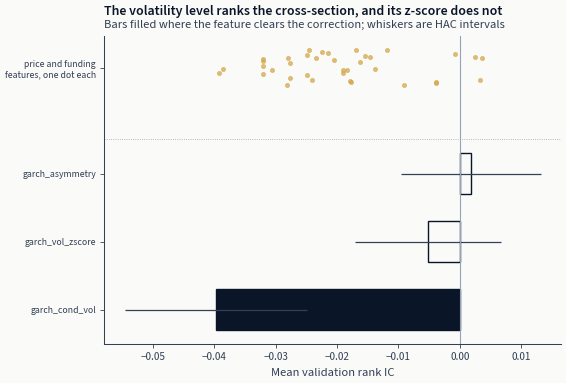

In [34]:
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
ax.barh(
    rows,
    plot_summary["mean_ic"].to_list(),
    height=0.6,
    edgecolor=COLORS["blue"],
    linewidth=1.0,
    color=bar_fill,
)
ax.errorbar(
    plot_summary["mean_ic"].to_list(),
    rows,
    xerr=interval,
    fmt="none",
    ecolor=COLORS["neutral"],
    elinewidth=0.9,
    capsize=2,
)
ax.scatter(financial_values, financial_jitter, s=9, color=COLORS["amber"], alpha=0.75)
ax.axvline(0, color=COLORS["recede"], linewidth=0.8)
ax.axhline(len(rows) - 0.5, color=COLORS["recede"], linewidth=0.6, linestyle=":")
ax.set_yticks(
    [*rows, REFERENCE_ROW],
    [*plot_summary["feature"].to_list(), "price and funding\nfeatures, one dot each"],
    fontsize=7,
)
ax.set(xlabel="Mean validation rank IC")
add_message_title(
    ax,
    "The volatility level ranks the cross-section, and its z-score does not",
    subtitle="Bars filled where the feature clears the correction; whiskers are HAC intervals",
)
fig.tight_layout()
show_with_alt(
    fig,
    "A horizontal bar chart of mean validation rank information coefficient for the "
    "model-based features, with HAC whiskers and bars filled only where the feature "
    "clears the false-discovery-rate correction, and above them a jittered row of dots "
    "on the same axis for each price and funding feature from the previous notebook. "
    "The conditional volatility bar reaches the negative edge of the dot cloud.",
)

The two regime probabilities are absent from the chart on the left, and that is a
property of the measure rather than of the features. A market-level quantity takes one
value across the whole cross-section at a settlement, so a rank correlation within the
settlement has nothing to rank. It does not follow that they carry no information: what
it means is that this particular screen cannot see it. Their use is as conditioning
variables, telling a nonlinear model that the same funding z-score should be read
differently in a stressed week. A cross-sectional rank correlation is the wrong
instrument for that, so their value has to be judged where a model can use them that
way rather than here.

**What the screen establishes, and what it does not.** Of the three features it can
rank, the conditional volatility level carries a clearly negative mean rank
information coefficient and is the only one that clears the multiplicity correction:
within a settlement, the more agitated perpetuals tend to be the weaker performers
over the next 8 hours. Its own trailing z-score and the fitted asymmetry coefficient
do not clear it, and the asymmetry is worth reading carefully - it is one number per
symbol per fold, so its information coefficient asks whether perpetuals with a
stronger leverage effect are persistently ranked, and over two folds there is little
for that to move against.

The dot row is what keeps this from being read as more than it is. The conditional
volatility bar sits at the negative edge of the existing features rather than beyond
it, and the dot next to it is `price_vol_14d`, printed above as the most negative of
the 37 - a trailing realized volatility computed with no model at all. On this
measure the fitted feature and the arithmetic one are hard to tell apart, which is a
reason to ask whether they carry the same information rather than an answer to it.
The two are built from the same returns and would be expected to correlate; whether
the GJR fit contributes anything the trailing window does not is a question about the
pair, and a chart of separate correlations cannot reach it. That is a useful answer
rather than a disappointing one: the case for the fitted feature has to rest on the
asymmetry and the conditioning it supplies to a nonlinear model, which a
stand-alone rank correlation cannot see, and the model notebooks are where it is
tested. Every magnitude here is small in absolute terms, which is the expected shape
for a volatility-state feature screened as a directional signal on its own.

## Key takeaways

- **A model-based feature carries its estimation window, and nothing in the output
  says so.** Two files of conditional volatilities can be identical in shape and
  plausibility while one of them was fitted across the whole sample. The only defence
  is structural: fit inside the fold, freeze, run forward, and assert the fitted
  window in code that fails.
- **Filtered, not smoothed.** Any state-space model will happily report a state
  probability conditioned on the entire series, and that is the better estimate of
  history and an unusable feature. Ask what a live system could have computed at the
  decision, and emit that.
- **Refit per fold, then check that the refit mattered.** Plotting the fitted
  parameters against fold turns an assumption into evidence, and tells the notebooks
  downstream whether a feature means the same thing in every fold before they pool
  them.
- **Carry the fold identity into the artifact.** A per-fold feature written without
  the fold that produced it is indistinguishable from a full-sample one, and the loader
  that assembles the training frame cannot restore what was not written.
- **Correct the significance for the number of features screened.** Five features are
  five chances at a false positive, and a per-feature p-value read as if it were one
  is the cheapest way to promote noise.

**Known limitations of what is built here.**

- Two folds is what this case study's history supports, so the stability panel in
  section D compares two estimates and cannot distinguish a trend from a single move.
- The volatility model is refitted only at fold boundaries and never updated between
  them, so a fold's later bars are filtered with parameters that are by then a year
  old. Whether an online update earns its cost is untested here.
- The regime model reads funding alone. Price, volume and open interest carry regime
  information too, and a richer observation would very likely separate states the
  two-dimensional fit merges.
- The fold identity in the artifact is the one the primary label's buffer implies.
  Where a variant label configures a different buffer, its own fold boundaries differ
  slightly from these, and the features it reads were fitted for this geometry.
- Within a fold, the parameters that produce a training row's feature were estimated
  from the whole training window, so an earlier training row carries a value fitted
  partly on returns that came after it. Validation rows do not: their parameters end
  before the validation window opens, which is why the evaluation above is sound. The
  alternative is to refit before every training row, which this notebook does not do.
- The holdout fold's features exist and its geometry is in the sidecar, but a consumer that
  regenerates the fold set from `generate_cv_splits` instead of reading `fold_geometry` sees
  the validation folds only - so the holdout rows are in the parquet and invisible to it.
  `temporal_artifact_fold_boundaries` reads the sidecar first, which is what makes them
  reachable; anything hand-rolling the fold list will miss them.
- The screen at the end scores each feature on its own, so it says nothing about what
  these features contribute inside a model that also holds the other 39. Answering
  that needs a with-and-without comparison, and no stage of this pipeline runs one.

**Next**: [`05_evaluation`](05_evaluation.ipynb) screens the complete feature set
before any model is fitted in Chapters 11 to 15.